In [32]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import torch
import sys
import os
from pathlib import Path

# Add project root to path
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# Add hloc to path - MUST be added to sys.path before importing
hloc_path = '/home/long/Workspace/crocodl-benchmark/external/hloc'
if hloc_path not in sys.path:
    sys.path.insert(0, hloc_path)

from hloc import extract_features
from hloc.extractors.superpoint import SuperPoint
from hloc.extractors.aliked import Aliked

print("Imports successful!")

Imports successful!


Extracting SuperPoint keypoints...
Loaded SuperPoint model


Extracting ALIKED keypoints...
SuperPoint detected 512 keypoints
ALIKED detected 512 keypoints


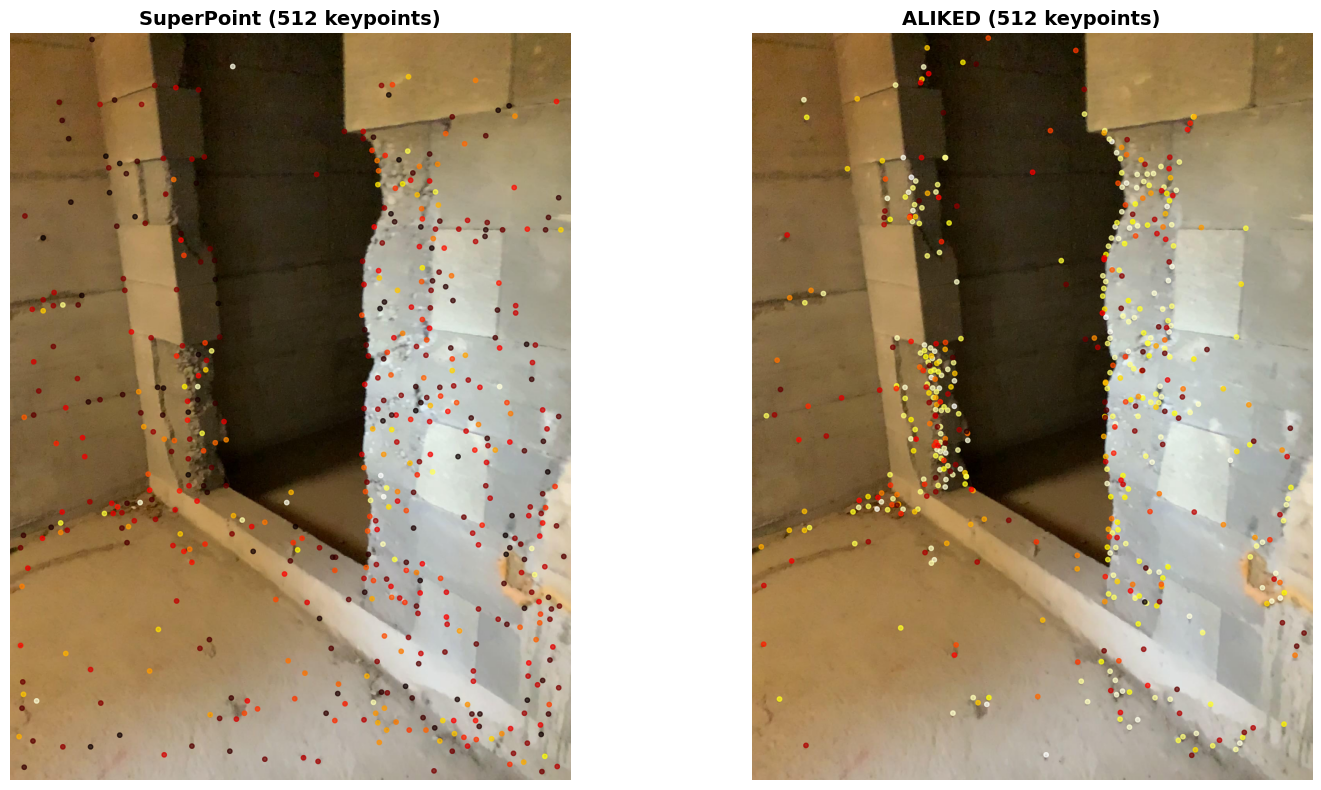

In [38]:
def extract_and_visualize_keypoints(image_path, output_path=None):
    """
    So sánh trực quan keypoints của SuperPoint và ALIKED trên cùng một cảnh
    Visual comparison of SuperPoint and ALIKED keypoints on the same scene
    """
    # Load image
    image = cv2.imread(image_path)
    if image is None:
        raise ValueError(f"Could not load image: {image_path}")
    
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    # Resize if too large
    max_size = 1024
    h, w = gray.shape
    if max(h, w) > max_size:
        scale = max_size / max(h, w)
        new_w, new_h = int(w * scale), int(h * scale)
        gray = cv2.resize(gray, (new_w, new_h))
        image_rgb = cv2.resize(image_rgb, (new_w, new_h))
    
    # Convert to tensor
    gray_tensor = torch.from_numpy(gray).float()[None, None] / 255.0
    
    # SuperPoint configuration
    superpoint_conf = {
        'name': 'superpoint',
        'nms_radius': 3,
        'max_keypoints': 512,
    }
    
    # ALIKED configuration  
    aliked_conf = {
        'name': 'aliked',
        'model_name': 'aliked-n32',
        'max_num_keypoints': 512,
        'detection_threshold': 0.01,
        'nms_radius': 2,
    }
    
    # Extract SuperPoint keypoints
    print("Extracting SuperPoint keypoints...")
    superpoint = SuperPoint(superpoint_conf).eval()
    with torch.no_grad():
        sp_pred = superpoint({'image': gray_tensor})
    sp_keypoints = sp_pred['keypoints'][0].cpu().numpy()
    sp_scores = sp_pred['scores'][0].cpu().numpy()
    
    # Extract ALIKED keypoints
    print("Extracting ALIKED keypoints...")
    aliked = Aliked(aliked_conf).eval()
    with torch.no_grad():
        aliked_pred = aliked({'image': gray_tensor})
    aliked_keypoints = aliked_pred['keypoints'][0].cpu().numpy()
    aliked_scores = aliked_pred['keypoint_scores'][0].cpu().numpy()
    
    print(f"SuperPoint detected {len(sp_keypoints)} keypoints")
    print(f"ALIKED detected {len(aliked_keypoints)} keypoints")
    
    # Visualize
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    # SuperPoint visualization
    axes[0].imshow(image_rgb)
    axes[0].scatter(sp_keypoints[:, 0], sp_keypoints[:, 1], 
                    c=sp_scores, s=10, cmap='hot', alpha=0.7)
    axes[0].set_title(f'SuperPoint ({len(sp_keypoints)} keypoints)', fontsize=14, fontweight='bold')
    axes[0].axis('off')
    
    # ALIKED visualization
    axes[1].imshow(image_rgb)
    axes[1].scatter(aliked_keypoints[:, 0], aliked_keypoints[:, 1],
                    c=aliked_scores, s=10, cmap='hot', alpha=0.7)
    axes[1].set_title(f'ALIKED ({len(aliked_keypoints)} keypoints)', fontsize=14, fontweight='bold')
    axes[1].axis('off')
    
    plt.tight_layout()
    
    if output_path:
        plt.savefig(output_path, dpi=150, bbox_inches='tight')
        print(f"Saved visualization to {output_path}")
    
    plt.show()
    
    return {
        'superpoint_keypoints': sp_keypoints,
        'superpoint_scores': sp_scores,
        'aliked_keypoints': aliked_keypoints,
        'aliked_scores': aliked_scores
    }

# Example usage
image_path = '/home/long/Workspace/crocodl-benchmark/notebooks/synced_dataset/ios_query_ios_map/keep_trimesh_depth10.0_thresh0.3/pair_00399/map.jpg'
results = extract_and_visualize_keypoints(image_path)

Loaded 3020 pairs from /home/long/Workspace/crocodl-benchmark/notebooks/estimate_pose/ios_query/spot_map/keep_trimesh_depth10.0_thresh0.3_filtered/filtered_keep.txt

Statistics:
Total samples: 3020
Easy samples: 1126 (37.3%)
Hard samples: 1894 (62.7%)

Hard samples criteria:
  - Overlap < 0.5: 53 samples
  - Rotation error > 30.0°: 1872 samples


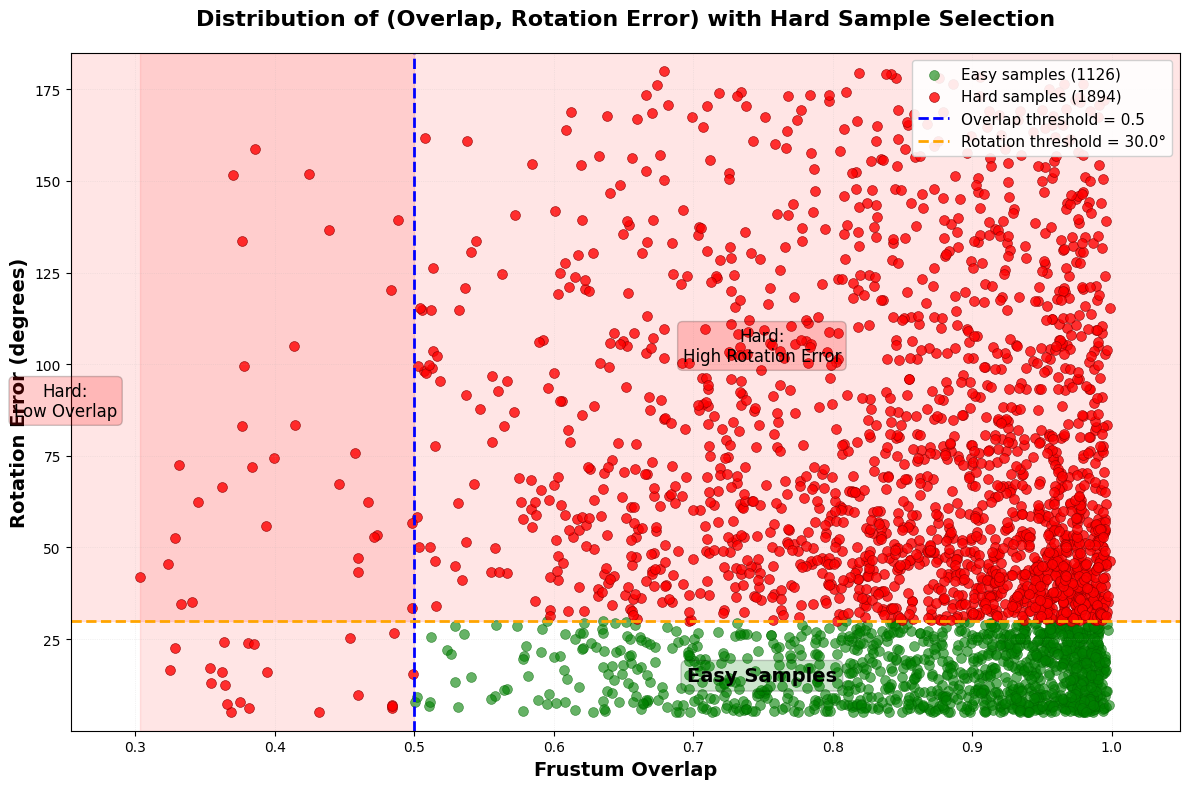

In [42]:
from pathlib import Path


def load_overlap_rotation_from_filtered(filtered_path):
    """Parse filtered_keep.txt and return overlaps and rotation errors.
    Expected columns per line: query_img, map_img, rotation_error_deg, match_score, frustum_overlap.
    Uses regex to be robust to whitespace/wrapping in the file.
    """
    with open(filtered_path, encoding='utf-8') as f:
        lines = f.readlines()

    overlaps = []
    rotation_errors = []
    entries = []
    for line in lines:
        q_rel, r_rel, r_err, match_score, frustum_overlap = line.strip().split(", ")
        rotation_errors.append(float(r_err))
        overlaps.append(float(frustum_overlap))
        entries.append((q_rel, r_rel, float(r_err), float(match_score), float(frustum_overlap)))

    return np.array(overlaps), np.array(rotation_errors), entries


def load_dataset_for_devices(base_dir, query_device='ios', map_device='ios', variant='keep_trimesh_depth10.0_thresh0.3_filtered'):
    base_dir = Path(base_dir)
    filtered_path = base_dir / f"{query_device}_query" / f"{map_device}_map" / variant / "filtered_keep.txt"
    if not filtered_path.exists():
        raise FileNotFoundError(f"Not found: {filtered_path}")
    return load_overlap_rotation_from_filtered(filtered_path), filtered_path


def plot_overlap_vs_rotation_error_with_hard_samples(overlaps, rotation_errors, 
                                                      overlap_threshold=0.5, 
                                                      rotation_threshold=30.0,
                                                      figsize=(12, 8)):
    """
    Vẽ phân bố (Overlap, Rotation Error) và vùng chọn Hard Samples
    Plot distribution of (Overlap, Rotation Error) and Hard Samples selection region
    
    Hard samples are defined as:
    - Low overlap (<threshold) OR High rotation error (>threshold)
    """
    
    # Define hard samples
    hard_mask = (overlaps < overlap_threshold) | (rotation_errors > rotation_threshold)
    easy_mask = ~hard_mask
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Plot easy samples
    ax.scatter(overlaps[easy_mask], rotation_errors[easy_mask], 
              c='green', s=50, alpha=0.6, label=f'Easy samples ({easy_mask.sum()})', 
              edgecolors='darkgreen', linewidth=0.5)
    
    # Plot hard samples
    ax.scatter(overlaps[hard_mask], rotation_errors[hard_mask], 
              c='red', s=50, alpha=0.8, label=f'Hard samples ({hard_mask.sum()})',
              edgecolors='darkred', linewidth=0.5)
    
    # Draw threshold lines
    ax.axvline(x=overlap_threshold, color='blue', linestyle='--', linewidth=2, 
               label=f'Overlap threshold = {overlap_threshold}')
    ax.axhline(y=rotation_threshold, color='orange', linestyle='--', linewidth=2,
               label=f'Rotation threshold = {rotation_threshold}°')
    
    # Highlight hard sample regions with semi-transparent rectangles
    # Region 1: Low overlap (left side)
    ax.axvspan(overlaps.min(), overlap_threshold, alpha=0.1, color='red', zorder=0)
    
    # Region 2: High rotation error (top)
    ax.axhspan(rotation_threshold, rotation_errors.max() * 1.05, alpha=0.1, color='red', zorder=0)
    
    # Add text annotations for regions
    ax.text(overlap_threshold/2, rotation_errors.max() * 0.5, 
            'Hard:\nLow Overlap', 
            fontsize=12, ha='center', va='center', 
            bbox=dict(boxstyle='round', facecolor='red', alpha=0.2))
    
    ax.text(overlaps.max() * 0.75, rotation_threshold + (rotation_errors.max() - rotation_threshold) * 0.5,
            'Hard:\nHigh Rotation Error',
            fontsize=12, ha='center', va='center',
            bbox=dict(boxstyle='round', facecolor='red', alpha=0.2))
    
    ax.text(overlaps.max() * 0.75, rotation_threshold * 0.5,
            'Easy Samples',
            fontsize=14, ha='center', va='center', fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='green', alpha=0.2))
    
    ax.set_xlabel('Frustum Overlap', fontsize=14, fontweight='bold')
    ax.set_ylabel('Rotation Error (degrees)', fontsize=14, fontweight='bold')
    ax.set_title('Distribution of (Overlap, Rotation Error) with Hard Sample Selection', 
                fontsize=16, fontweight='bold', pad=20)
    
    ax.legend(loc='upper right', fontsize=11, framealpha=0.9)
    ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.5)
    
    # Set reasonable axis limits
    ax.set_xlim(overlaps.min() - 0.05, overlaps.max() + 0.05)
    ax.set_ylim(rotation_errors.min() - 5, rotation_errors.max() + 5)
    
    plt.tight_layout()
    
    # Print statistics
    print(f"\nStatistics:")
    print(f"Total samples: {len(overlaps)}")
    print(f"Easy samples: {easy_mask.sum()} ({100*easy_mask.sum()/len(overlaps):.1f}%)")
    print(f"Hard samples: {hard_mask.sum()} ({100*hard_mask.sum()/len(overlaps):.1f}%)")
    print(f"\nHard samples criteria:")
    print(f"  - Overlap < {overlap_threshold}: {(overlaps < overlap_threshold).sum()} samples")
    print(f"  - Rotation error > {rotation_threshold}°: {(rotation_errors > rotation_threshold).sum()} samples")
    
    return fig, ax

# ---- Run for chosen devices ----
query_device = 'ios'
map_device = 'spot'
base_dir = '/home/long/Workspace/crocodl-benchmark/notebooks/estimate_pose'

(overlaps, rotation_errors, entries), filtered_path = load_dataset_for_devices(
    base_dir, query_device=query_device, map_device=map_device,
)
print(f"Loaded {len(overlaps)} pairs from {filtered_path}")

fig, ax = plot_overlap_vs_rotation_error_with_hard_samples(
    overlaps, rotation_errors,
    overlap_threshold=0.5,
    rotation_threshold=30.0,
)
plt.show()

# Save figure if needed
# plt.savefig('overlap_rotation_distribution.png', dpi=300, bbox_inches='tight')


Original pairs: 5362
Kept (Hard Positives): 3020
Dropped: 2342
Sources:
  original: /home/long/Workspace/crocodl-benchmark/notebooks/estimate_pose/ios_query/spot_map/est_poses.txt
  keep:     /home/long/Workspace/crocodl-benchmark/notebooks/estimate_pose/ios_query/spot_map/keep_trimesh_depth10.0_thresh0.3_filtered/filtered_keep.txt


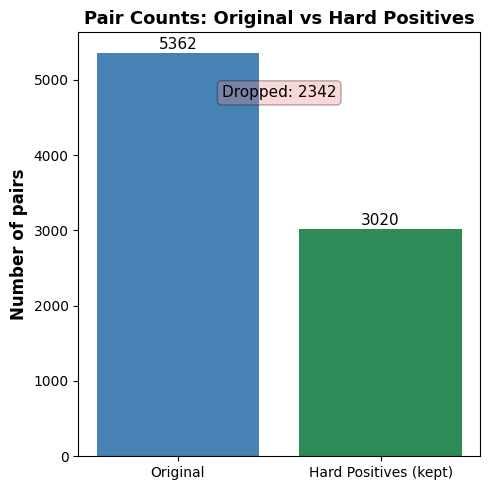

In [52]:
# Bar plot: original pairs vs kept (hard positives)
from pathlib import Path
import matplotlib.pyplot as plt


def count_pairs_from_files(filtered_keep_path, original_path):
    # Count original pairs from est_poses.txt (non-empty lines)
    with open(original_path, encoding='utf-8') as f:
        total_pairs = sum(1 for line in f if line.strip())
    # Count kept pairs from filtered_keep.txt (non-empty lines)
    kept_pairs = 0
    if Path(filtered_keep_path).exists():
        with open(filtered_keep_path, encoding='utf-8') as f:
            kept_pairs = sum(1 for line in f if line.strip())
    dropped_pairs = max(total_pairs - kept_pairs, 0)
    return total_pairs, kept_pairs, dropped_pairs


# Configure paths
filtered_keep_path = '/home/long/Workspace/crocodl-benchmark/notebooks/estimate_pose/ios_query/spot_map/keep_trimesh_depth10.0_thresh0.3_filtered/filtered_keep.txt'
original_path = '/home/long/Workspace/crocodl-benchmark/notebooks/estimate_pose/ios_query/spot_map/est_poses.txt'

# Count
total_pairs, kept_pairs, dropped_pairs = count_pairs_from_files(filtered_keep_path, original_path)
print(f"Original pairs: {total_pairs}\nKept (Hard Positives): {kept_pairs}\nDropped: {dropped_pairs}\nSources:\n  original: {original_path}\n  keep:     {filtered_keep_path}")

# Bar plot (only Original vs Kept)
labels = ['Original', 'Hard Positives (kept)']
values = [total_pairs, kept_pairs]
colors = ['steelblue', 'seagreen']

fig, ax = plt.subplots(figsize=(5, 5))
ax.bar(labels, values, color=colors)
ax.set_ylabel('Number of pairs', fontsize=12, fontweight='bold')
ax.set_title('Pair Counts: Original vs Hard Positives', fontsize=13, fontweight='bold')
for i, v in enumerate(values):
    ax.text(i, v + max(values)*0.001, f"{v}", ha='center', va='bottom', fontsize=11)
# Annotate dropped in text box
ax.text(0.5, max(values)*0.9, f"Dropped: {dropped_pairs}", ha='center', va='center',
        bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.3), fontsize=11)
plt.tight_layout()
plt.show()


Original pairs (good+bad): 5384 | Hard Positives: 3020
Orig rotation error: min=0.02, max=179.97, mean=47.95
Keep rotation error: min=5.00, max=179.97, mean=52.42


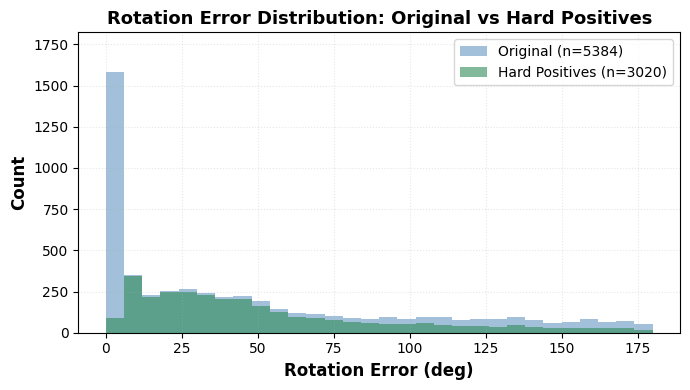

In [59]:
# Histograms of rotation error: original (good+bad) vs Hard Positives (keep)
from pathlib import Path
import matplotlib.pyplot as plt


def load_rotation_errors(txt_path):
    errs = []
    with open(txt_path, encoding='utf-8') as f:
        for line in f:
            if line.startswith("#"):
                continue
            line = line.strip()
            if not line:
                continue
            parts = line.split(', ')
            if len(parts) < 3:
                continue
            err = float(parts[2])
            errs.append(err)
    return np.array(errs)

# Paths for ios-ios
orig_good = '/home/long/Workspace/crocodl-benchmark/notebooks/estimate_pose/ios_query/spot_map/good_pairs.txt'
orig_bad = '/home/long/Workspace/crocodl-benchmark/notebooks/estimate_pose/ios_query/spot_map/bad_pairs.txt'
keep_path = '/home/long/Workspace/crocodl-benchmark/notebooks/estimate_pose/ios_query/spot_map/keep_trimesh_depth10.0_thresh0.3_filtered/filtered_keep.txt'

orig_errs = np.concatenate([
    load_rotation_errors(orig_good),
    load_rotation_errors(orig_bad)
])
keep_errs = load_rotation_errors(keep_path)

print(f"Original pairs (good+bad): {len(orig_errs)} | Hard Positives: {len(keep_errs)}")
print(f"Orig rotation error: min={orig_errs.min():.2f}, max={orig_errs.max():.2f}, mean={orig_errs.mean():.2f}")
print(f"Keep rotation error: min={keep_errs.min():.2f}, max={keep_errs.max():.2f}, mean={keep_errs.mean():.2f}")

bins = 30
fig, ax = plt.subplots(figsize=(7, 4))

# Compute hist to set tight y-limit
counts_orig, bin_edges = np.histogram(orig_errs, bins=bins)
counts_keep, _ = np.histogram(keep_errs, bins=bin_edges)
ax.hist(orig_errs, bins=bin_edges, alpha=0.5, color='steelblue', label=f'Original (n={len(orig_errs)})')
ax.hist(keep_errs, bins=bin_edges, alpha=0.6, color='seagreen', label=f'Hard Positives (n={len(keep_errs)})')

ax.set_xlabel('Rotation Error (deg)', fontsize=12, fontweight='bold')
ax.set_ylabel('Count', fontsize=12, fontweight='bold')
ax.set_title('Rotation Error Distribution: Original vs Hard Positives', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, linestyle=':')

max_count = max(counts_orig.max(), counts_keep.max()) if len(counts_orig) > 0 else 1
ax.set_ylim(0, max_count * 1.15)

plt.tight_layout()
plt.show()


In [2]:
from pprint import pprint
def extract_time(file_path):
    results = {
        "Extract map time": [],
        "Select map time": [],
        "Match map time": [],
        "Mapping time": [],
        "Extract query time": [],
        "Select query time": [],
        "Match query time": [],
        "Estimate pose time": []
    }
    with open(file_path, encoding='utf-8') as f:
        lines = f.readlines()
        for line in lines:
            if "time = " in line:
                label, time = line.split(" = ")
                if label in list(results.keys()):
                    time = time.split(" ")[0]
                    results[label].append(float(time))
    return results

# file_path = "/home/long/Workspace/crocodl-benchmark/notebooks/outputs/al_lg_wtime.txt"
# print(extract_time(file_path))

/tmp/ipykernel_5658/2016799886.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(configs, rotation=20, ha='right')
/tmp/ipykernel_5658/2016799886.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(configs, rotation=20, ha='right')


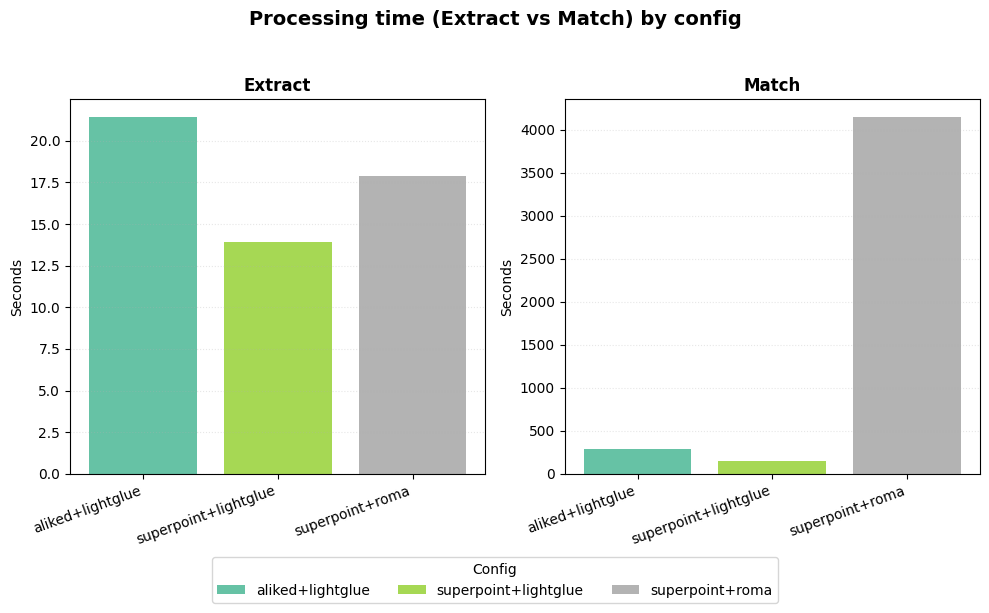

In [3]:
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Load benchmarking results JSON
json_path = Path('/home/long/Workspace/crocodl-benchmark/notebooks/outputs/benchmarking_results.json')
with open(json_path, encoding='utf-8') as f:
    benchmark_data = json.load(f)

configs = sorted(benchmark_data.keys())
time_types = list(next(iter(benchmark_data.values()))['time'].keys())


def top3_mean(arr):
    arr = np.array(arr, dtype=float)
    if arr.size == 0:
        return np.nan
    topk = np.sort(arr)[-3:] if arr.size >= 3 else arr
    return float(np.mean(topk))


# Compute top-3-mean per original type
mean_times = {
    cfg: {
        t: top3_mean(times)
        for t, times in benchmark_data[cfg]['time'].items()
    }
    for cfg in configs
}

# Groups (only Extract, Match)
groups = {
    'Extract': ['Extract map time', 'Extract query time'],
    'Match': ['Match map time', 'Match query time'],
}

# Compute top-3-mean per grouped type (flatten then top3)
mean_group_times = {}
for cfg in configs:
    mean_group_times[cfg] = {}
    for group_name, keys in groups.items():
        values = []
        for k in keys:
            values.extend(benchmark_data[cfg]['time'][k])
        mean_group_times[cfg][group_name] = top3_mean(values)

# Plots: 1 row, 2 columns for Extract and Match
bar_colors = plt.cm.Set2(np.linspace(0, 1, len(configs)))
fig, axes = plt.subplots(1, 2, figsize=(10, 6))
axes = np.atleast_1d(axes).flatten()
legend_handles = None

for ax, group_name in zip(axes, groups.keys()):
    values = [mean_group_times[cfg][group_name] for cfg in configs]
    bars = ax.bar(configs, values, color=bar_colors)
    if legend_handles is None:
        legend_handles = bars
    ax.set_title(f"{group_name}", fontsize=12, fontweight='bold')
    ax.set_ylabel('Seconds')
    ax.set_xticklabels(configs, rotation=20, ha='right')
    ax.grid(True, axis='y', alpha=0.3, linestyle=':')

fig.suptitle('Processing time (Extract vs Match) by config', fontsize=14, fontweight='bold')
fig.tight_layout(rect=[0, 0.06, 1, 0.95])
fig.legend(legend_handles, configs, title='Config', loc='lower center', ncol=len(configs), bbox_to_anchor=(0.5, -0.02))
plt.show()


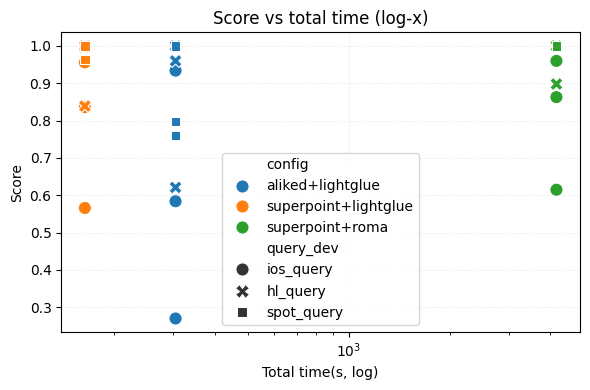

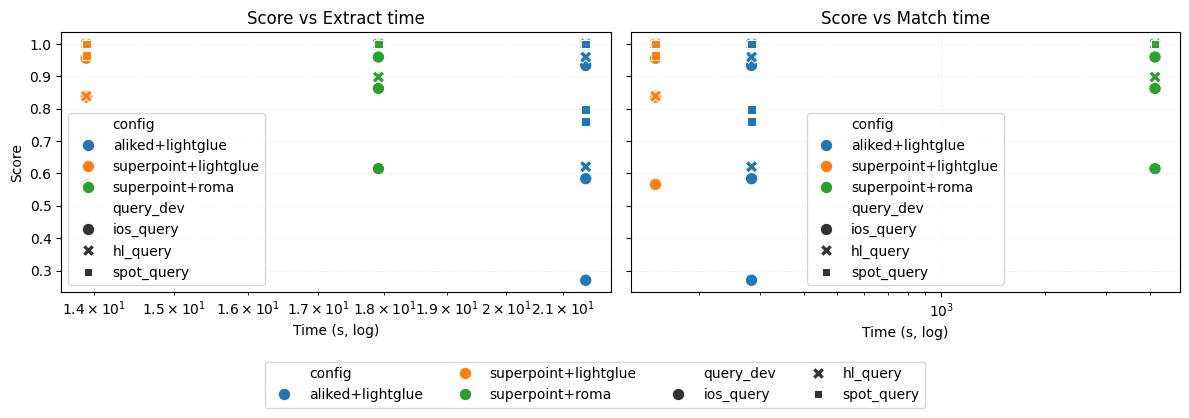

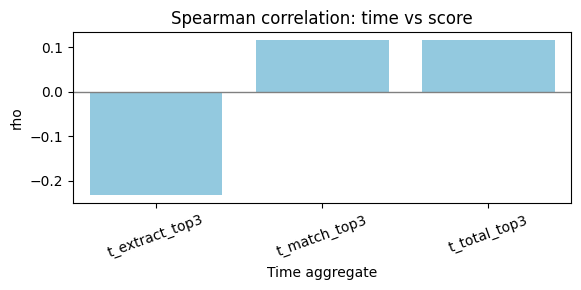

In [5]:
import pandas as pd
import seaborn as sns
from scipy.stats import spearmanr

# --- Build score/time table ---
records = []
for cfg, cfg_data in benchmark_data.items():
    if cfg == 'time':
        continue
    # aggregate times
    t_extract = benchmark_data[cfg]['time']['Extract map time'] + benchmark_data[cfg]['time']['Extract query time']
    t_match = benchmark_data[cfg]['time']['Match map time'] + benchmark_data[cfg]['time']['Match query time']
    t_extract_top3 = top3_mean(t_extract)
    t_match_top3 = top3_mean(t_match)
    t_total = t_extract_top3 + t_match_top3
    # per query-map score rows
    for q_dev, maps in cfg_data.items():
        if q_dev == 'time':
            continue
        for m_dev, score in maps.items():
            records.append({
                'config': cfg,
                'query_dev': q_dev,
                'map_dev': m_dev,
                'score': score,
                't_extract_top3': t_extract_top3,
                't_match_top3': t_match_top3,
                't_total_top3': t_total,
            })

df = pd.DataFrame(records)
# print('Table head:')
# print(df.head())

# --- Scatter: score vs total time (log-x) ---
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='t_total_top3', y='score', hue='config', style='query_dev', s=90)
plt.xscale('log')
plt.xlabel('Total time(s, log)')
plt.ylabel('Score')
plt.title('Score vs total time (log-x)')
plt.grid(True, alpha=0.3, linestyle=':')
plt.tight_layout()
plt.show()

# --- Facet scatter: Extract vs score, Match vs score ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
sns.scatterplot(data=df, x='t_extract_top3', y='score', hue='config', style='query_dev', s=80, ax=axes[0])
axes[0].set_xscale('log')
axes[0].set_title('Score vs Extract time')
axes[0].grid(True, alpha=0.3, linestyle=':')

sns.scatterplot(data=df, x='t_match_top3', y='score', hue='config', style='query_dev', s=80, ax=axes[1])
axes[1].set_xscale('log')
axes[1].set_title('Score vs Match time')
axes[1].grid(True, alpha=0.3, linestyle=':')

for ax in axes:
    ax.set_xlabel('Time (s, log)')
    ax.set_ylabel('Score')

handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.1))
fig.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

# --- Correlation (Spearman) between time and score per time type ---
corr_rows = []
for time_col in ['t_extract_top3', 't_match_top3', 't_total_top3']:
    rho, p = spearmanr(df[time_col], df['score'])
    corr_rows.append({'time_type': time_col, 'spearman_rho': rho, 'p_value': p})

corr_df = pd.DataFrame(corr_rows)
# print('\nSpearman correlations:')
# print(corr_df)

plt.figure(figsize=(6, 3))
sns.barplot(data=corr_df, x='time_type', y='spearman_rho', color='skyblue')
plt.axhline(0, color='gray', linewidth=1)
plt.title('Spearman correlation: time vs score')
plt.ylabel('rho')
plt.xlabel('Time aggregate')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


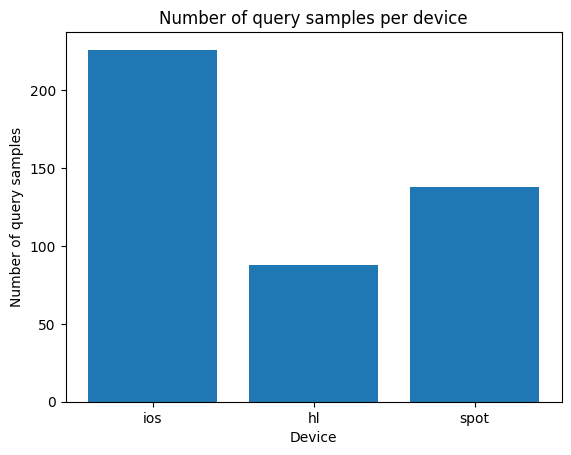

In [8]:
# import os
# import matplotlib.pyplot as plt

base = "/home/long/Workspace/crocodl-benchmark/capture/ARCHE_D2/sessions"
devices = ["ios", "hl", "spot"]

def get_num_query_samples(device):
    path = f"{base}/{device}_query/proc/keyframes_pruned_subsampled.txt"
    with open(path, encoding="utf-8") as f:
        return len(f.readlines())
        # return len(f.readlines()) * (1 if device == 'ios' else 4)

counts = {d: get_num_query_samples(d) for d in devices}

plt.figure()
plt.bar(counts.keys(), counts.values())
plt.xlabel("Device")
plt.ylabel("Number of query samples")
plt.title("Number of query samples per device")
plt.show()
